In [3]:
import pandas as pd
import numpy as np
import glob
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn

In [5]:
def quantile95(ser):
    return(ser.quantile(q=0.95))

In [6]:
def quantile99(ser):
    return(ser.quantile(q=0.99))

In [7]:
def dtr(logger):
        logger['dmin'] = logger.groupby(['date']).tempc.transform('min')
        logger['dmax'] = logger.groupby(['date']).tempc.transform('max')
        logger['dtr'] = logger['dmax'] - logger['dmin']
        return(logger)

In [8]:
def dailymean(logger):
        logger['dmean'] = logger.groupby(['date']).tempc.transform('mean')
        return(logger)

In [9]:
path = '/home/jbos/Moz_temps/'

In [10]:
north_bay = pd.read_csv(path + "Norte_logger.csv", skiprows=[0])
south_bay = pd.read_csv(path + "spiders_logger.csv", skiprows=[0])
inner_bay = pd.read_csv(path + "Viveiros_logger.csv", skiprows=[0])
caldeira = pd.read_csv(path + "CaldeiraDock_logger.csv", skiprows=[0])

In [11]:
north_bay.columns=['ID', 'dt', 'tempc']
north_bay['ID'] = 'north_bay'

south_bay.columns=['ID', 'dt', 'tempc']
south_bay['ID'] = 'south_bay'

inner_bay.columns=['ID', 'dt', 'tempc']
inner_bay['ID'] = 'inner_bay'

caldeira.columns=['ID', 'dt', 'tempc']
caldeira['ID'] = 'caldeira'

In [12]:
north_bay['dt']=pd.to_datetime(north_bay['dt'],format='%m/%d/%y %I:%M:%S %p')
south_bay['dt']=pd.to_datetime(south_bay['dt'],format='%m/%d/%y %I:%M:%S %p')
inner_bay['dt']=pd.to_datetime(inner_bay['dt'],format='%m/%d/%y %I:%M:%S %p')
caldeira['dt']=pd.to_datetime(caldeira['dt'],format='%m/%d/%y %I:%M:%S %p')

In [13]:
north_bay = north_bay[north_bay['dt'] > pd.to_datetime('2023-06-25 00:00:00')]
north_bay = north_bay[north_bay['dt'] < pd.to_datetime('2024-06-07 00:00:00')]

south_bay = south_bay[south_bay['dt'] > pd.to_datetime('2023-12-24 00:00:00')]
south_bay = south_bay[south_bay['dt'] < pd.to_datetime('2024-07-04 00:00:00')]

inner_bay = inner_bay[inner_bay['dt'] > pd.to_datetime('2023-06-24 00:00:00')]
inner_bay = inner_bay[inner_bay['dt'] < pd.to_datetime('2024-05-26 00:00:00')]

caldeira = caldeira[caldeira['dt'] > pd.to_datetime('2023-06-24 00:00:00')]
caldeira = caldeira[caldeira['dt'] < pd.to_datetime('2024-06-20 00:00:00')]

In [14]:
north_bay['date'] = north_bay['dt'].dt.date
south_bay['date'] = south_bay['dt'].dt.date
inner_bay['date'] = inner_bay['dt'].dt.date
caldeira['date'] = caldeira['dt'].dt.date

In [37]:
north_bay=dtr(north_bay)
south_bay=dtr(south_bay)
inner_bay=dtr(inner_bay)
caldeira=dtr(caldeira)

In [15]:
north_jm=north_bay[north_bay['dt'] > pd.to_datetime('2024-01-01 00:00:00')]
north_jm=north_jm[north_jm['dt'] < pd.to_datetime('2024-05-01 00:00:00')]

south_jm=south_bay[south_bay['dt'] > pd.to_datetime('2024-01-01 00:00:00')]
south_jm=south_jm[south_jm['dt'] < pd.to_datetime('2024-05-01 00:00:00')]

inner_jm=inner_bay[inner_bay['dt'] > pd.to_datetime('2024-01-01 00:00:00')]
inner_jm=inner_jm[inner_jm['dt'] < pd.to_datetime('2024-05-01 00:00:00')]

caldeira_jm=caldeira[caldeira['dt'] > pd.to_datetime('2024-01-01 00:00:00')]
caldeira_jm=caldeira_jm[caldeira_jm['dt'] < pd.to_datetime('2024-05-01 00:00:00')]

In [16]:
north_jm['tempc'].mean()

np.float64(29.52418932414981)

In [17]:
south_jm['tempc'].mean()

np.float64(29.42702823934567)

In [18]:
inner_jm['tempc'].mean()

np.float64(29.681749634093844)

In [19]:
caldeira['tempc'].mean()

np.float64(27.55540439124054)

In [22]:
inner_jm['dtr'].mean()

np.float64(0.6680545845888942)

In [23]:
north_jm['dtr'].mean()

np.float64(0.8025969005596212)

In [24]:
south_jm['dtr'].mean()

np.float64(0.9421514421007318)

In [25]:
caldeira_jm['dtr'].mean()

np.float64(1.3562217821782179)

In [26]:
inner_jm['dmax'].mean()

np.float64(30.026268876452864)

In [27]:
north_jm['dmax'].mean()

np.float64(29.931605424020663)

In [92]:
south_jm['dmax'].mean()

np.float64(29.81920981489453)

In [93]:
caldeira_jm['dmax'].mean()

np.float64(30.13484167025398)

In [94]:
inner_jm['dmin'].mean()

np.float64(29.358214291863966)

In [95]:
north_jm['dmin'].mean()

np.float64(29.129008523461042)

In [96]:
south_jm['dmin'].mean()

np.float64(28.8770583727938)

In [97]:
caldeira_jm['dmin'].mean()

np.float64(28.778619888075763)

In [28]:
quantile99(inner_jm['tempc'])

np.float64(30.722)

In [29]:
quantile99(north_jm['tempc'])

np.float64(30.773)

In [30]:
quantile99(south_jm['tempc'])

np.float64(30.52)

In [31]:
quantile99(caldeira_jm['tempc'])

np.float64(31.251500000000014)

In [32]:
north_jm=dailymean(north_jm)
south_jm=dailymean(south_jm)
inner_jm=dailymean(inner_jm)
caldeira_jm=dailymean(caldeira_jm)

In [33]:
north_bay=dailymean(north_bay)
south_bay=dailymean(south_bay)
inner_bay=dailymean(inner_bay)
caldeira=dailymean(caldeira)

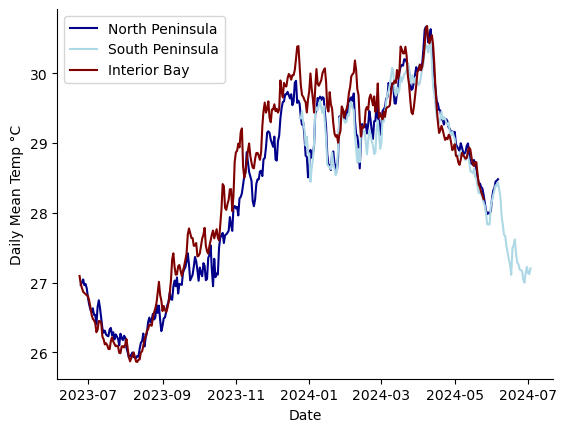

In [45]:
fig, ax = plt.subplots()

ax.plot(north_bay['date'], north_bay['dmean'], label='North Peninsula', color='darkblue', linestyle='-')
ax.plot(south_bay['date'], south_bay['dmean'], label='South Peninsula', color='lightblue', linestyle='-')
ax.plot(inner_bay['date'], inner_bay['dmean'], label='Interior Bay', color='maroon', linestyle='-')

# 1) Add a legend
ax.legend()

# 2) Remove the top and right axes (spines)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 3) Add titles to the bottom (x) and left (y) axes
ax.set_xlabel('Date')
ax.set_ylabel('Daily Mean Temp °C')

# 4) Save the plot as a PNG
plt.savefig('Supplemental_fig1.png', dpi=800, bbox_inches='tight')

plt.show()

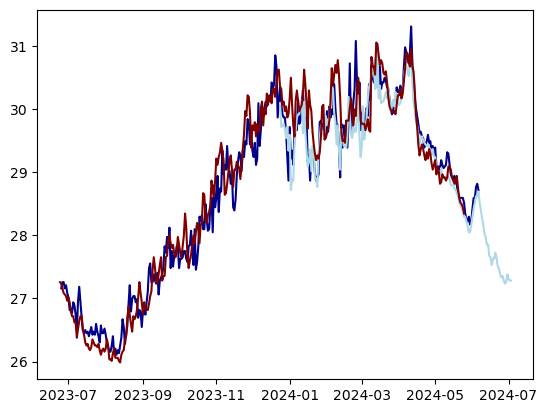

In [38]:
plt.plot(north_bay['date'], north_bay['dmax'], label='North Bay', color='darkblue', linestyle='-')
plt.plot(south_bay['date'], south_bay['dmax'], label='South Bay', color='lightblue', linestyle='-')
plt.plot(inner_bay['date'], inner_bay['dmax'], label='Interior Bay', color='maroon', linestyle='-')

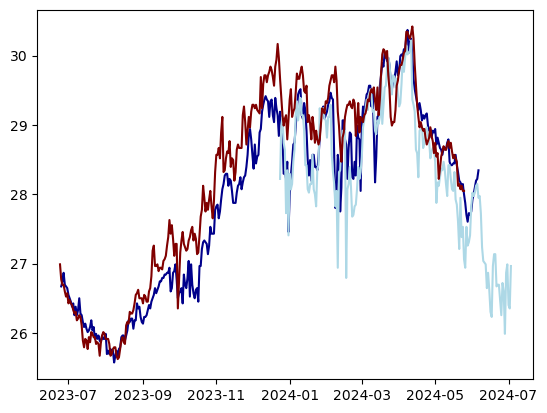

In [39]:
plt.plot(north_bay['date'], north_bay['dmin'], label='North Bay', color='darkblue', linestyle='-')
plt.plot(south_bay['date'], south_bay['dmin'], label='South Bay', color='lightblue', linestyle='-')
plt.plot(inner_bay['date'], inner_bay['dmin'], label='Interior Bay', color='maroon', linestyle='-')

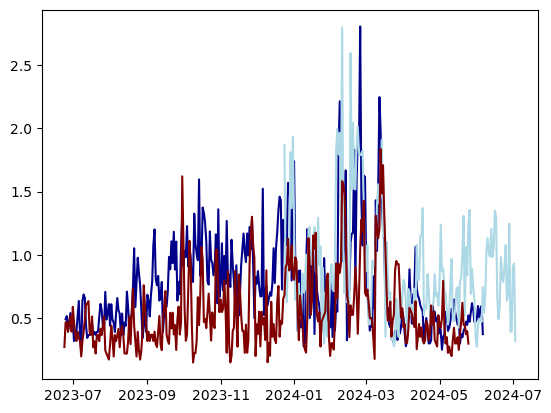

In [41]:
plt.plot(north_bay['date'], north_bay['dtr'], label='North Bay', color='darkblue', linestyle='-')
plt.plot(south_bay['date'], south_bay['dtr'], label='South Bay', color='lightblue', linestyle='-')
plt.plot(inner_bay['date'], inner_bay['dtr'], label='Interior Bay', color='maroon', linestyle='-')